# ASSISTments 2012-2013 Clustering

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import linkage, dendrogram
import umap.umap_ as umap

In [3]:
DATA_PATH = '/content/drive/MyDrive/datasets/2012-2013-data-with-predictions-4-final.csv'

# Read only the columns needed for clustering; the full ASSISTments file is large.
usecols = [
    'user_id','problem_id','assignment_id','assistment_id','sequence_id',
    'student_class_id','skill','skill_id','correct','bottom_hint','hint_count',
    'attempt_count','ms_first_response','overlap_time','position','original',
    'first_action','Average_confidence(FRUSTRATED)','Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)','Average_confidence(BORED)'
]

df = pd.read_csv(DATA_PATH,usecols=usecols,low_memory=False)
print(df.shape)
display(df.head())
display(df.dtypes)

(6123270, 21)


,skill,problem_id,user_id,assignment_id,assistment_id,original,correct,bottom_hint,hint_count,attempt_count,...,sequence_id,student_class_id,position,skill_id,overlap_time,first_action,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,NaN,557460,61394,565736,341511,1,1.0,0.0,0,1,...,55482,23643,4,NaN,9852,0,0.361323,0.0,0.336529,0.000000
1,Rounding,365981,61394,573819,204043,1,1.0,0.0,0,1,...,34221,22967,5,54.0,21175,0,0.361323,0.0,0.766925,0.000000
2,Multiplication and Division Integers,426415,61394,734130,247525,1,0.0,0.0,0,1,...,39601,22967,58,279.0,8645,0,0.361323,0.0,0.766925,0.442968
3,Proportion,86686,61394,821352,48081,1,1.0,0.0,0,1,...,6912,26303,21,79.0,25728,0,0.775000,0.0,0.766925,0.912281
4,NaN,399669,76592,557216,227869,1,1.0,0.0,0,1,...,37143,21696,3,NaN,286578,0,0.361323,0.0,0.766925,0.000000


,0
skill,object
problem_id,int64
user_id,int64
assignment_id,int64
assistment_id,int64
original,int64
correct,float64
bottom_hint,float64
hint_count,int64
attempt_count,int64


## Data cleaning

first numeric conversion

In [4]:
numeric_cols = [
    'correct','bottom_hint','hint_count','attempt_count','ms_first_response',
    'overlap_time','position','original','first_action',
    'Average_confidence(FRUSTRATED)','Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)','Average_confidence(BORED)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')

id_cols = ['user_id','problem_id','assignment_id','assistment_id','sequence_id','student_class_id','skill_id']
for col in id_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')

### Skill labels

In [5]:
df['skill_label'] = df['skill_id'].astype('Int64').astype(str)
missing_skill = df['skill_id'].isna()
df.loc[missing_skill,'skill_label'] = df.loc[missing_skill,'skill'].fillna('Unknown').astype(str)
df['skill_label'] = df['skill_label'].replace('<NA>','Unknown')

skill_df = df.copy()
print('Original rows:',len(df))
print('Rows after skill preparation:',len(skill_df))
print('Unique skills:',skill_df['skill_label'].nunique())

Original rows: 6123270
Rows after skill preparation: 6123270
Unique skills: 266


### Duration outliers

log transform and remove all negative times

In [6]:
df['response_time_log'] = np.log1p(df['ms_first_response'].clip(lower=0))
df['overlap_time_log'] = np.log1p(df['overlap_time'].clip(lower=0))

## Student information

In [7]:
group = df.groupby('user_id')

student = pd.DataFrame(index=group.size().index)

# interactions
student['total_interactions'] = group.size()
student['success_rate'] = group['correct'].mean()
student['incorrect_rate'] = 1 - student['success_rate']

# unique problems assignments sequences and skills
student['unique_problems'] = group['problem_id'].nunique()
student['unique_assignments'] = group['assignment_id'].nunique()
student['unique_assistments'] = group['assistment_id'].nunique()
student['unique_sequences'] = group['sequence_id'].nunique()
student['unique_skills'] = skill_df.groupby('user_id')['skill_label'].nunique()
student['skill_diversity'] = student['unique_skills'] / student['total_interactions']

# duration stats
student['avg_response_time_log'] = group['response_time_log'].mean()
student['median_response_time_log'] = group['response_time_log'].median()
student['response_time_variance'] = group['response_time_log'].var()
student['avg_overlap_time_log'] = group['overlap_time_log'].mean()

# position stats
student['avg_position'] = group['position'].mean()
student['max_position'] = group['position'].max()

# hints and attempts
student['avg_hints'] = group['hint_count'].mean()
student['total_hints'] = group['hint_count'].sum()
student['avg_attempts'] = group['attempt_count'].mean()
student['total_attempts'] = group['attempt_count'].sum()
student['bottom_hint_rate'] = group['bottom_hint'].mean()
student['first_action_rate'] = group['first_action'].mean()

# affect detector confidence stats
student['avg_frustrated'] = group['Average_confidence(FRUSTRATED)'].mean()
student['avg_confused'] = group['Average_confidence(CONFUSED)'].mean()
student['avg_concentrating'] = group['Average_confidence(CONCENTRATING)'].mean()
student['avg_bored'] = group['Average_confidence(BORED)'].mean()

# use stats to make a struggle score
student['struggle_score'] = student['incorrect_rate'].fillna(0)
student['struggle_score'] += student['avg_response_time_log'].fillna(0)
student['struggle_score'] += student['avg_hints'].fillna(0)
student['struggle_score'] += student['avg_attempts'].fillna(0)

## Skill mastery matrix

How good a student is at getting a skill correct

In [8]:
skill_mastery = pd.pivot_table(
    skill_df,
    index='user_id',
    columns='skill_label',
    values='correct',
    aggfunc='mean'
).fillna(0)

student['skill_mastery_variance'] = skill_mastery.var(axis=1)

## Final dataframe

In [9]:
X = student.join(skill_mastery,how='left')

for col in X.columns:
    X[col] = X[col].fillna(X[col].mean())

## PCA

In [10]:
X_scaled=StandardScaler().fit_transform(X)

# 95 percent of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print('Original features:',X.shape[1])
print('PCA components:',X_pca.shape[1])

Original features: 293
PCA components: 218


## UMAP

Didnt take better at capturing groupings?

In [11]:
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## Select K (cluster count) using silhoutte score

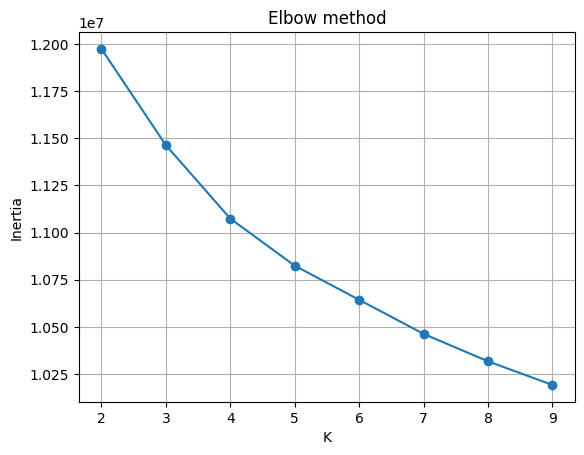

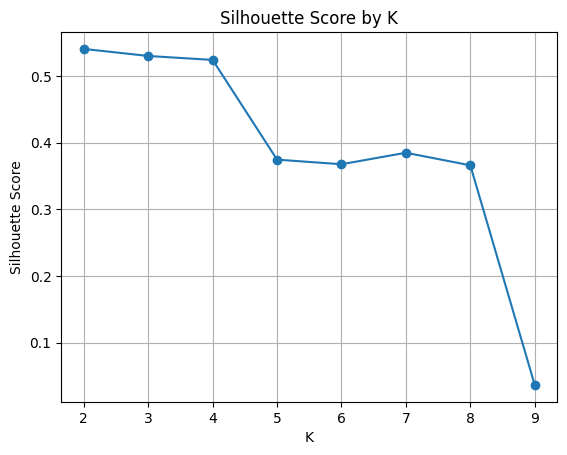

Best K= 2


In [12]:
scores = []
inertias = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k,n_init=20,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca,labels))
    inertias.append(kmeans.inertia_)

plt.plot(range(2,10),inertias,marker='o')
plt.title('Elbow method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

plt.plot(range(2,10),scores,marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = np.argmax(scores)+2
print('Best K=',best_k)

## Train clustering models

K means

Herarchical Didnt take (relationships between data points)

guassian mixture Didnt take (non circular patterns)

DBSCAN Didnt take (density based clusters and noise points)

In [13]:
k_labels = KMeans(n_clusters=best_k,n_init=20,random_state=42).fit_predict(X_pca)
print("k")
# h_labels = AgglomerativeClustering(n_clusters=best_k).fit_predict(X_pca)
# print("h")
gmm = GaussianMixture(n_components=best_k,random_state=42)
print("g")
g_labels = gmm.fit_predict(X_pca)
print("g")
# dbscan = DBSCAN(eps=9.0,min_samples=10)
# print("d")
# # db_labels = dbscan.fit_predict(X_pca)
# print("d")

k
g
g


## Model comparison

silhouette score (how similar a point is to its cluster vs others)

Davies bouldin index Didnt take (how similar a cluster is to other clusters)

calinski harabasz index Didnt take (cluster dispertion ratio)

In [14]:
# function in case DBSCAN returns less than 2 real clusters

def clustering_metrics(data, labels):
    clusters = set(labels) - {-1}
    if len(clusters) < 2:
        return [np.nan,np.nan,np.nan]

    return [
        silhouette_score(data, labels),
        davies_bouldin_score(data, labels),
        calinski_harabasz_score(data, labels)
    ]


comparison_model = pd.DataFrame([
['KMeans', *clustering_metrics(X_pca,k_labels)],
# ['Hierarchical', *clustering_metrics(X_pca,h_labels)],
['GMM', *clustering_metrics(X_pca,g_labels)],
# ['DBSCAN', *clustering_metrics(X_pca,db_labels)]
],columns=['Model','Silhouette','DBI','CHI'])

# print('DBSCAN clusters:',len(set(db_labels) - {-1}))
# print('DBSCAN noise points:',np.sum(db_labels == -1))
display(comparison_model.sort_values('Silhouette',ascending=False))

,Model,Silhouette,DBI,CHI
0,KMeans,0.540374,2.891279,3495.168802
1,GMM,0.098673,4.051565,1196.272285


## Heirachical dendogram

In [15]:
# plt.figure(figsize=(12,5))
# Z = linkage(X_pca,method='ward')
# dendrogram(Z,truncate_mode='level',p=5)
# plt.show()

## PCA visualization

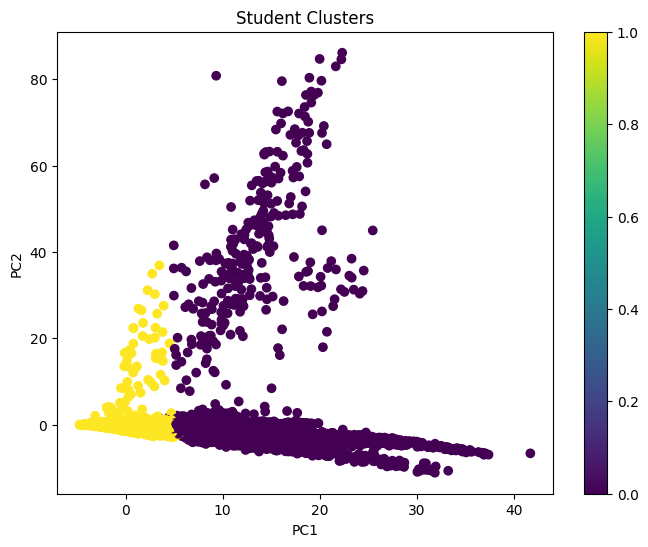

In [16]:
X2 = PCA(
    n_components=2
).fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X2[:,0],
    X2[:,1],
    c=k_labels
)

plt.title(
    'Student Clusters'
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

## UMAP visualization

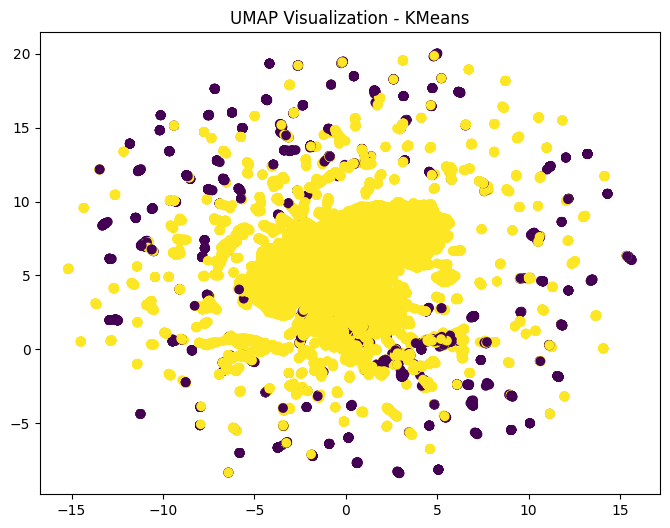

In [17]:
best_model=comparison_model.sort_values('Silhouette',ascending=False).iloc[0]['Model']
labels = {'KMeans':k_labels,'GMM':g_labels}[best_model]

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0],X_umap[:,1],c=labels)
plt.title(f'UMAP Visualization - {best_model}')
plt.show()

## Compare PCA to non PCA

In [18]:
k_labels_nonPCA = KMeans(n_clusters=best_k,n_init=20,random_state=42).fit_predict(X_scaled)

comparison_pca = pd.DataFrame([
['KMeans PCA',silhouette_score(X_pca,k_labels),davies_bouldin_score(X_pca,k_labels),calinski_harabasz_score(X_pca,k_labels)],
['KMeans non PCA',silhouette_score(X_scaled,k_labels_nonPCA),davies_bouldin_score(X_scaled,k_labels_nonPCA),calinski_harabasz_score(X_scaled,k_labels_nonPCA)],
],columns=['Model','Silhouette','DBI','CHI'])

display(comparison_pca.sort_values('Silhouette',ascending=False))

,Model,Silhouette,DBI,CHI
0,KMeans PCA,0.540374,2.891279,3495.168802
1,KMeans non PCA,0.537550,2.974528,3311.488368


## Cluster profiles

information about clusters

In [19]:
student['cluster'] = labels
cluster_profiles = student.groupby('cluster').mean()
display(cluster_profiles)

,total_interactions,success_rate,incorrect_rate,unique_problems,unique_assignments,unique_assistments,unique_sequences,unique_skills,skill_diversity,avg_response_time_log,...,avg_attempts,total_attempts,bottom_hint_rate,first_action_rate,avg_frustrated,avg_confused,avg_concentrating,avg_bored,struggle_score,skill_mastery_variance
cluster,,,,,,,,,,,,,,,,,,,,,
0,488.630443,0.718628,0.281372,464.778697,77.926592,427.774739,67.419935,37.910759,0.118053,10.168625,...,1.298755,637.455380,0.102007,0.042129,0.386262,0.045542,0.697396,0.275484,12.030748,0.077965
1,82.874355,0.641121,0.358879,80.544362,9.019944,61.992971,8.639410,5.025440,0.168522,10.222034,...,1.394472,113.274078,0.121417,0.084847,0.388797,0.040939,0.562353,0.268401,12.355349,0.010099


## Cluster naming

In [20]:
persona_report = cluster_profiles.copy()
persona_report['Persona'] = 'General Learner'

for idx,row in persona_report.iterrows():
    if row['success_rate'] > persona_report['success_rate'].mean():
        persona_report.loc[idx,'Persona'] = 'High Achiever'
    elif row['incorrect_rate'] > persona_report['incorrect_rate'].mean():
        persona_report.loc[idx,'Persona'] = 'Struggling Learner'

persona_report['size'] = pd.Series(labels).value_counts()
display(persona_report)

,total_interactions,success_rate,incorrect_rate,unique_problems,unique_assignments,unique_assistments,unique_sequences,unique_skills,skill_diversity,avg_response_time_log,...,bottom_hint_rate,first_action_rate,avg_frustrated,avg_confused,avg_concentrating,avg_bored,struggle_score,skill_mastery_variance,Persona,size
cluster,,,,,,,,,,,,,,,,,,,,,
0,488.630443,0.718628,0.281372,464.778697,77.926592,427.774739,67.419935,37.910759,0.118053,10.168625,...,0.102007,0.042129,0.386262,0.045542,0.697396,0.275484,12.030748,0.077965,High Achiever,5558
1,82.874355,0.641121,0.358879,80.544362,9.019944,61.992971,8.639410,5.025440,0.168522,10.222034,...,0.121417,0.084847,0.388797,0.040939,0.562353,0.268401,12.355349,0.010099,Struggling Learner,41116
